In [1]:
from torchvision.datasets import MNIST
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

import numpy as np
import math


from helpers import *
from loss_and_eval import *


class Layer:
    def __init__(self, input_neurons, output_neurons, softmax = False):
        self.j = output_neurons
        self.k = input_neurons

        self.W = np.random.normal(scale = 1/math.sqrt(self.j), size = (self.j, self.k)).tolist()
        self.b = np.random.normal(size = (self.j, 1)).tolist()

        self.softmax = softmax

        self.clear_grad()

    def __call__(self, prev_activations):
        return self.forward(prev_activations)

    def forward(self, prev_activations):
        z = matrix_add(matrix_mult(self.W, prev_activations), self.b)
        if self.softmax:
            return vector_softmax(z), z

        return vector_sigmoid(z), z

    def clear_grad(self):
        self.W_grad = [[0.0 for _ in range(self.k)] for _ in range(self.j)]
        self.b_grad = [[0.0] for _ in range(self.j)]

class Optimizer:
    def __init__(self, lr, batch_size, weight_decay = None):
        self.lr = lr
        self.weight_decay = weight_decay
        self.batch_size = batch_size

    def __call__(self, layer): # update the parameters
        # print(f"{len(layer.W)}x{len(layer.W[0])}, {len(layer.W_grad)}x{len(layer.W_grad[0])}")
        if self.weight_decay is not None:
            layer.W = matrix_scalar_mult(1-self.weight_decay, layer.W)

        layer.W = matrix_sub(layer.W, matrix_scalar_mult(self.lr/self.batch_size, layer.W_grad))
        layer.b = matrix_sub(layer.b, matrix_scalar_mult(self.lr/self.batch_size, layer.b_grad))





class MLP:
    def __init__(self, hidden_neurons):
        self.layers = [
            Layer(784, hidden_neurons),
            Layer(hidden_neurons, 10, softmax=True),
        ]
        self.clear_a_and_z()
        self.optim = Optimizer(1e-3, 64)



    def __call__(self, x):
        return self.forward(x)

    def forward(self, x):
        output = x

        for layer in self.layers: 
            output, weighted_input = layer(output)
            self.activations.append(output)
            self.weighted_inputs.append(weighted_input)

        return output

    def backward(self, x, y):
        L = len(self.layers)
        delta_l_s = [0.0 for _ in range(L)]

        for l in range(L-1, -1, -1):
            a_l = self.activations[l]
            z_l = self.weighted_inputs[l]

            # print(l)
            
            if (l == L - 1): 
                # print(matrix_sub(a_l, y))
                # delta_l = hadamard(matrix_sub(a_l, y), vector_dsigmoid(z_l)) # BP1, quadratic loss
                delta_l = matrix_sub(a_l, y) # BP1, BCE, NLL
            else:
                # print(matrix_mult(transpose(self.layers[l+1].W), delta_l_s[l+1]))
                delta_l = hadamard(matrix_mult(transpose(self.layers[l+1].W), delta_l_s[l+1]), vector_dsigmoid(z_l)) # BP2

            delta_l_s[l] = delta_l

            # BP3
            if (l == 0):
                W_grad = matrix_mult(delta_l, transpose(x))
            else:
                W_grad = matrix_mult(delta_l, transpose(self.activations[l-1]))


            self.layers[l].W_grad = matrix_add(self.layers[l].W_grad, W_grad)
            self.layers[l].b_grad = matrix_add(self.layers[l].b_grad, delta_l) # BP4

            # print(self.layers[l].W_grad)

            # print(f"l: {l} | grad: {self.layers[l].W_grad}")

        self.clear_a_and_z()

        


    def step(self): # update parameters 
        for layer in self.layers:
            self.optim(layer)

    def clear_a_and_z(self):
        self.activations = []
        self.weighted_inputs = []


    def clear_grad(self):
        for layer in self.layers:
            layer.clear_grad()

    def set_optim(self, optim):
        self.optim = optim
        





         


  0%|          | 0/50000 [00:00<?, ?samples/s]

Epoch: 1 | Loss: 0.3605 | Acc: 93.60%


<Figure size 640x480 with 0 Axes>

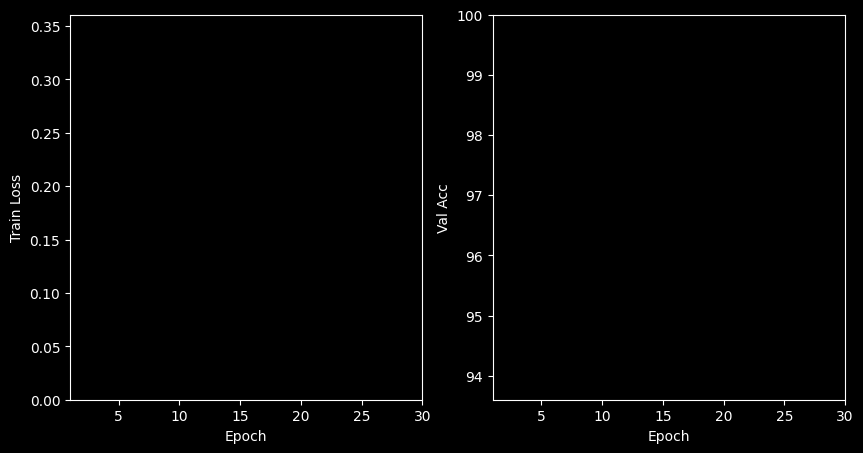

  0%|          | 0/50000 [00:00<?, ?samples/s]

Epoch: 2 | Loss: 0.2152 | Acc: 95.37%


<Figure size 640x480 with 0 Axes>

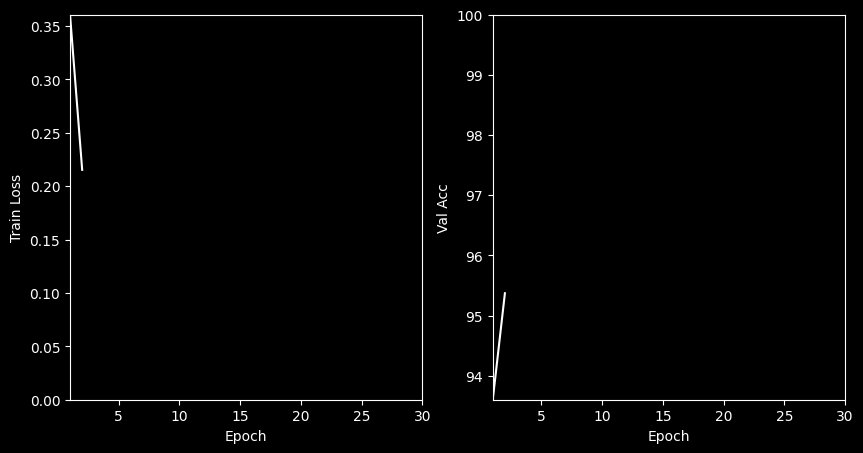

  0%|          | 0/50000 [00:00<?, ?samples/s]

Epoch: 3 | Loss: 0.1676 | Acc: 95.73%


<Figure size 640x480 with 0 Axes>

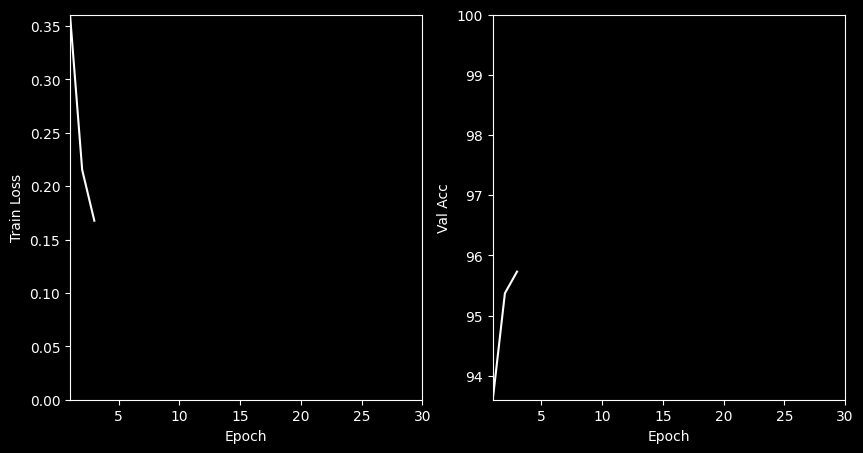

  0%|          | 0/50000 [00:00<?, ?samples/s]

Epoch: 4 | Loss: 0.1399 | Acc: 96.40%


<Figure size 640x480 with 0 Axes>

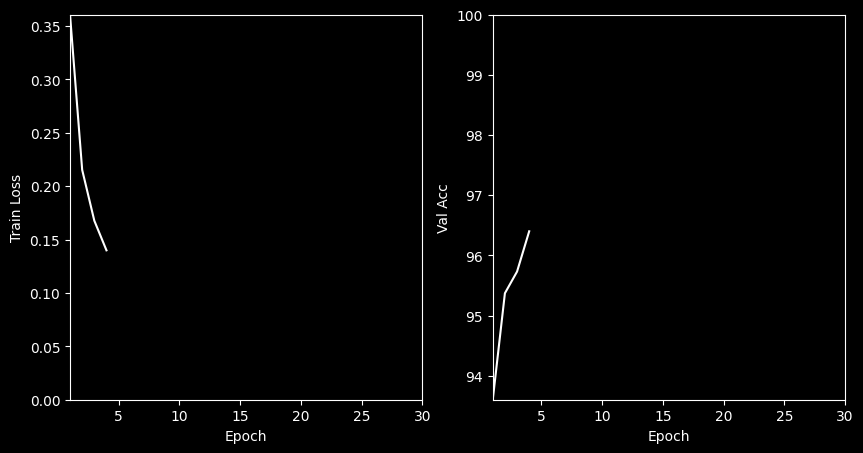

  0%|          | 0/50000 [00:00<?, ?samples/s]

Epoch: 5 | Loss: 0.1214 | Acc: 96.68%


<Figure size 640x480 with 0 Axes>

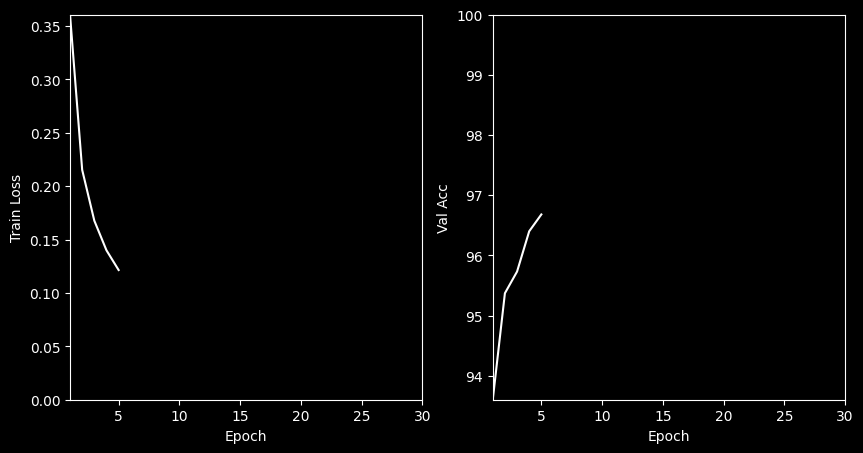

  0%|          | 0/50000 [00:00<?, ?samples/s]

Epoch: 6 | Loss: 0.1081 | Acc: 96.94%


<Figure size 640x480 with 0 Axes>

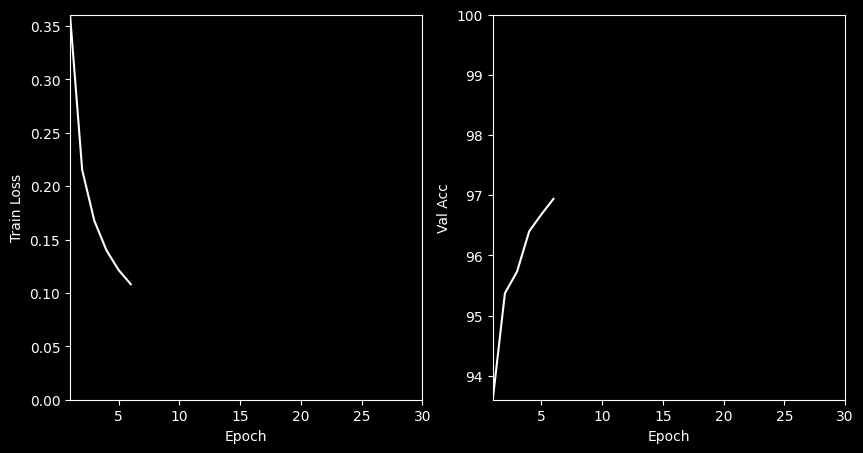

  0%|          | 0/50000 [00:00<?, ?samples/s]

Epoch: 7 | Loss: 0.0979 | Acc: 97.16%


<Figure size 640x480 with 0 Axes>

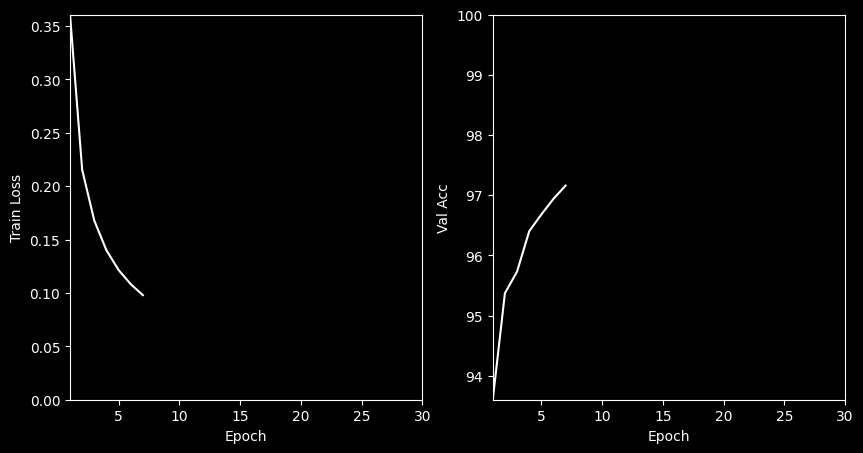

  0%|          | 0/50000 [00:00<?, ?samples/s]

Epoch: 8 | Loss: 0.0895 | Acc: 97.28%


<Figure size 640x480 with 0 Axes>

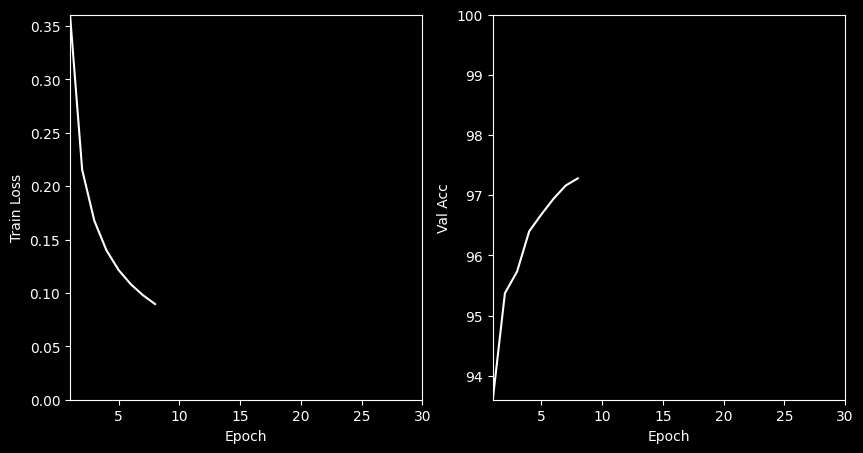

  0%|          | 0/50000 [00:00<?, ?samples/s]

In [ ]:
np.random.seed(42)


train = MNIST(root="data", train=True, download=True)
test = MNIST(root="data", train=False, download=True)

x_train, y_train = [], []
x_test, y_test = [], []

for image, label in train:
    x = [[pixel / 255.0] for pixel in image.getdata()]
    y = [[0.0] for _ in range(10)]
    y[label] = [1.0]

    x_train.append(x)
    y_train.append(y)


for image, label in test:
    x = [[pixel / 255.0] for pixel in image.getdata()]
    y = [[0.0] for _ in range(10)]
    y[label] = [1.0]

    x_test.append(x)
    y_test.append(y)

x_val = x_train[50000:]
y_val = y_train[50000:]

x_train = x_train[:50000]
y_train = y_train[:50000]


mlp = MLP(hidden_neurons=100)
batch_size = 10
epochs = 30
lr = 0.1
weight_decay = 1e-5

optim = Optimizer(lr=lr, batch_size=batch_size, weight_decay=weight_decay)
mlp.set_optim(optim=optim)

train_losses = []
val_accs = []
epochs_list = []


for i in range(epochs):
    num_train_samples = len(x_train)
    train_loss = 0.0

    combined = list(zip(x_train, y_train))
    np.random.shuffle(combined)
    x_train, y_train = zip(*combined)

    pbar = tqdm(total=num_train_samples, unit="samples")

    for batch_index in range(0, num_train_samples, batch_size):
        for offset in range(batch_size):
            s = batch_index + offset
            if (s >= num_train_samples): break

            x, y = x_train[s], y_train[s]
            preds = mlp(x)
            mlp.backward(x, y) 
            # sys.exit()
            loss = NLL(y, preds)
            train_loss += loss

            # if s % 1024 == 0: print(loss)
            pbar.update(1)
            # if (s % 1000 == 0): print(f"{s}/{num_samples}")

        mlp.step()
        mlp.clear_grad()


    pbar.close()

    train_loss += L2(mlp, optim) # L2 Regularization
    train_loss /= num_train_samples

    correct = 0.0
    num_val_samples = len(x_val)

    for s in range(num_val_samples):
        x, y = x_val[s], y_val[s]

        preds = mlp(x)
        correct += acc(y, preds)    

    val_acc = 100 * correct / num_val_samples   
        
    train_losses.append(train_loss)
    val_accs.append(val_acc)
    epochs_list.append(i+1)

    
    print(f"Epoch: {i+1} | Loss: {train_loss:.4f} | Acc: {val_acc:.2f}%")  

    plt.clf()
    plt.style.use("dark_background")
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.axis([1, epochs, 0, max(train_losses)])
    plt.plot(epochs_list, train_losses, c = "white")
    plt.xlabel("Epoch")
    plt.ylabel("Train Loss")

    plt.subplot(1, 2, 2)
    plt.axis([1, epochs, min(val_accs), 100])
    plt.plot(epochs_list, val_accs, c = "white")
    plt.xlabel("Epoch")
    plt.ylabel("Val Acc")

    plt.show()





In [40]:
correct = 0.0
num_test_samples = len(x_test)


for s in range(num_test_samples):
        x, y = x_test[s], y_test[s]

        preds = mlp(x)
        correct += acc(y, preds)
        
test_acc = 100 * correct / num_test_samples

print(f"Test Acc: {test_acc:.2f}%")

  

Test Acc: 97.81%
